In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('ipl.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [ ]:
df.shape

(74, 20)

In [ ]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [ ]:
df.isnull().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


In [ ]:
df.head(1)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20


<Axes: ylabel='match_winner'>

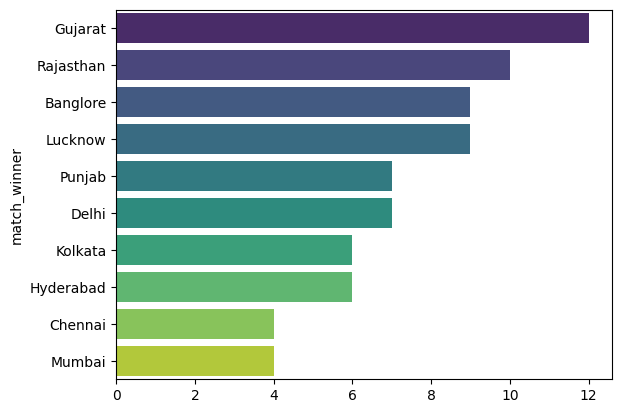

In [ ]:
match_wins = df['match_winner'].value_counts()
sns.barplot(x = match_wins.values, y = match_wins.index, palette = 'viridis')

<Axes: xlabel='toss_decision', ylabel='count'>

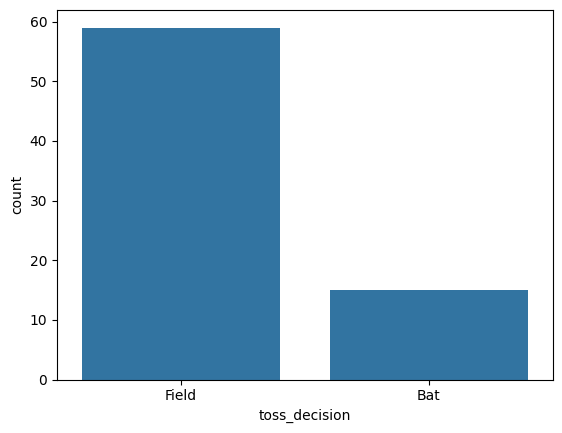

In [ ]:
sns.countplot(x = df['toss_decision'])

In [ ]:
percentage = df[df['toss_winner'] == df['match_winner']].shape[0]/df.shape[0]*100
round(percentage,2)


48.65

<Axes: xlabel='won_by', ylabel='count'>

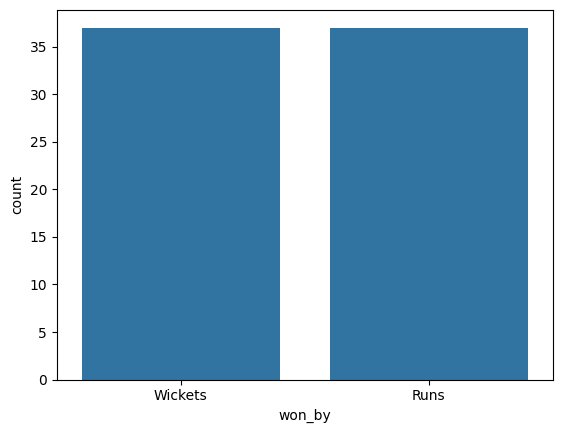

In [ ]:
sns.countplot(x = df['won_by'])

<Axes: ylabel='player_of_the_match'>

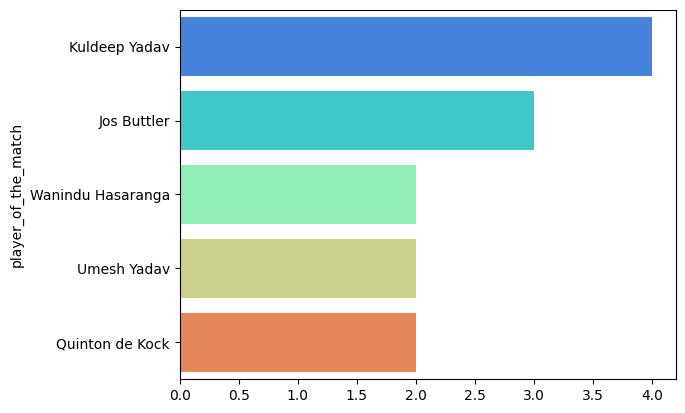

In [ ]:
most_awards = df['player_of_the_match'].value_counts().head()
sns.barplot(x = most_awards.values, y = most_awards.index, palette = 'rainbow')

In [ ]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending = False).head(2)

<Axes: ylabel='top_scorer'>

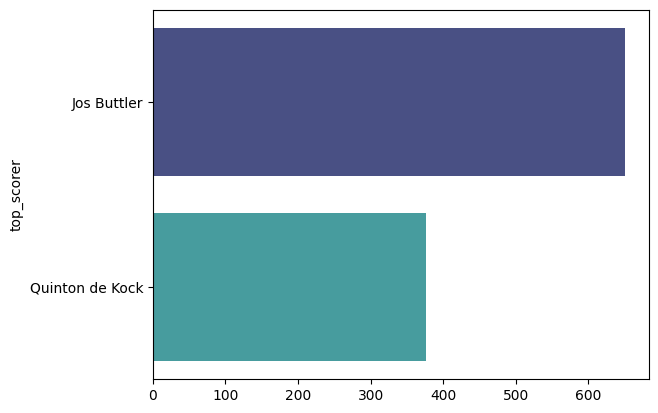

In [ ]:
sns.barplot(x = high.values, y = high.index, palette = 'mako')

In [ ]:
df['highest_wickets'] = df['best_bowling_figure'].str.split('--')
def ex(x):
  return int(x[0])

df['highest_wickets'] = df['highest_wickets'].apply(ex)
df['highest_wickets'] = df['highest_wickets'].astype(int)
df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending = False).head(5)

,highest_wickets
best_bowling,
Yuzvendra Chahal,17
Jasprit Bumrah,11
Kuldeep Yadav,11
Rashid Khan,11
Josh Hazlewood,10


<Axes: ylabel='best_bowling'>

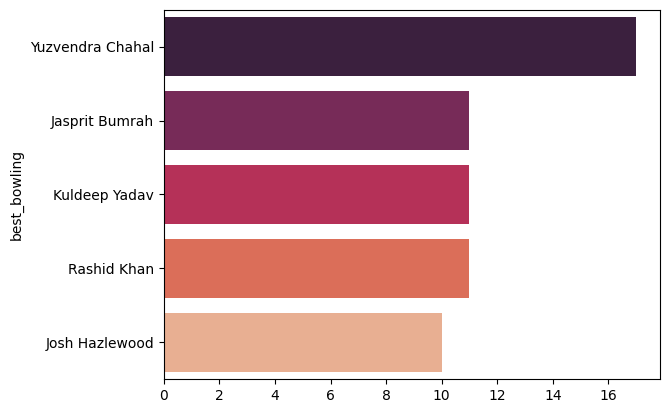

In [ ]:
k = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending = False).head()
sns.barplot(y = k.index, x = k.values, palette = 'rocket')

<Axes: ylabel='top_scorer'>

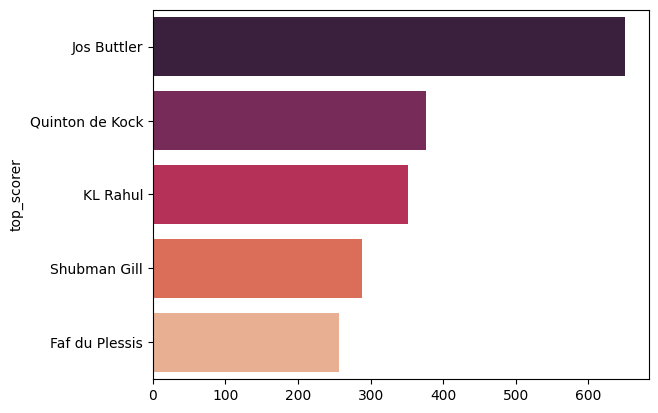

In [ ]:
runs = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending = False).head()
sns.barplot(x = runs.values, y = runs.index, palette = 'rocket')

In [ ]:
best_figures = df.groupby('best_bowling')['highest_wickets'].max().sort_values(ascending=False).head(5)

<Axes: ylabel='best_bowling'>

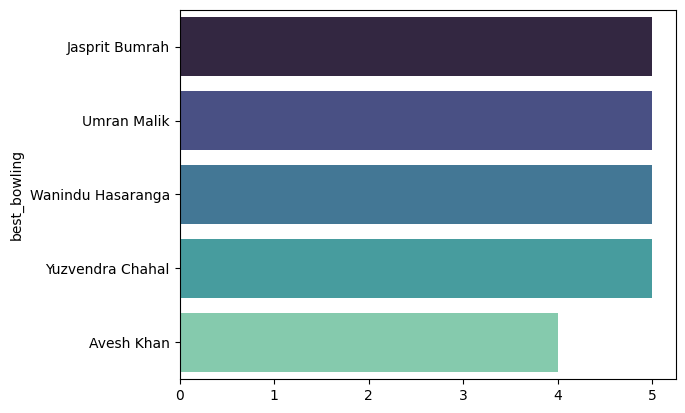

In [ ]:
sns.barplot(x = best_figures.values, y = best_figures.index, palette = 'mako' )

In [ ]:
df.groupby('best_bowling')[['highest_wickets', 'best_bowling_figure']].max().sort_values(by = 'highest_wickets', ascending = False).head()

,highest_wickets,best_bowling_figure
best_bowling,,
Jasprit Bumrah,5,5--10
Umran Malik,5,5--25
Wanindu Hasaranga,5,5--18
Yuzvendra Chahal,5,5--40
Avesh Khan,4,4--24
